In [60]:
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install pandas

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


som_size = 44
dimensions = 2  # Dimension of the input data
learning_rate_initial = 0.1  # Initial learning rate
iterations = 1000  # Number of iterations


#som_grid = np.random.ran(som_size, dimensions) * 20 - 10

# Generate the dataset
data_uniform = np.random.uniform(-88, 88, (200, dimensions))
blob_s, _ = make_blobs(n_samples=1200, centers=1, n_features=2, center_box=(-88, 88), cluster_std=3.0, random_state=42)
blob_t, _ = make_blobs(n_samples=1200, centers=1, n_features=2, center_box=( 88,-88), cluster_std=3.0, random_state=42)

blob_v11, _ = make_blobs(n_samples=200, centers=1, n_features=2, center_box=(1, -88), cluster_std=3.0, random_state=42)
blob_v12, _ = make_blobs(n_samples=200, centers=1, n_features=2, center_box=(44, -1), cluster_std=3.0, random_state=42)
blob_v13, _ = make_blobs(n_samples=200, centers=1, n_features=2, center_box=(88, -88), cluster_std=3.0, random_state=42)

blob_v21, _ = make_blobs(n_samples=200, centers=1, n_features=2, center_box=(1, 88), cluster_std=3.0, random_state=42)
blob_v22, _ = make_blobs(n_samples=200, centers=1, n_features=2, center_box=(44, -44), cluster_std=3.0, random_state=42)
blob_v23, _ = make_blobs(n_samples=200, centers=1, n_features=2, center_box=(88, -1), cluster_std=3.0, random_state=42)


data_points = np.vstack([data_uniform, blob_s, blob_t,
                         blob_v11, 
                         blob_v12, 
                         blob_v13, 
                         blob_v21, 
                         blob_v22, 
                         blob_v23,  
                         ])

# Parameters for the 2D normal distribution
mean = [0, 0]  # Mean of the distribution
cov = [[1, 0], [0, 1]]  # Covariance matrix for the distribution

# Generate 1000 samples from the 2D normal distribution
angles = np.random.uniform(0, 2*3.14, (som_size, 1))
#density_sample = np.hstack([np.sin(angles), np.cos(angles)])# np.random.multivariate_normal(mean, cov, som_size)
density_sample = np.random.multivariate_normal(mean, cov, som_size)
#density_sample = 
#som_locations = np.hstack([np.sin(angles), np.cos(angles)])# np.random.multivariate_normal(mean, cov, som_size)
#som_centroids = data_uniform[np.random.choice(data_uniform.shape[0], som_size, replace=False)]

In [62]:
data_points.shape

(3800, 2)

In [63]:
def snake_topology_sample(l):
    shape_sample = np.zeros( (l,2))
    for i in range(l):
        shape_sample[i, 0] = i
        shape_sample[i, 1] = 0.0
    return shape_sample

def grid_topology_sample(r, c):
    density_sample = np.zeros(())
    for i in range(r):
        for j in range(c):
            density_sample[c*i+j,0] = i + np.random.randn(1)*0.01
            density_sample[c*i+j,1] = j + np.random.randn(1)*0.01
    return density_sample

density_sample = snake_topology_sample(44) 

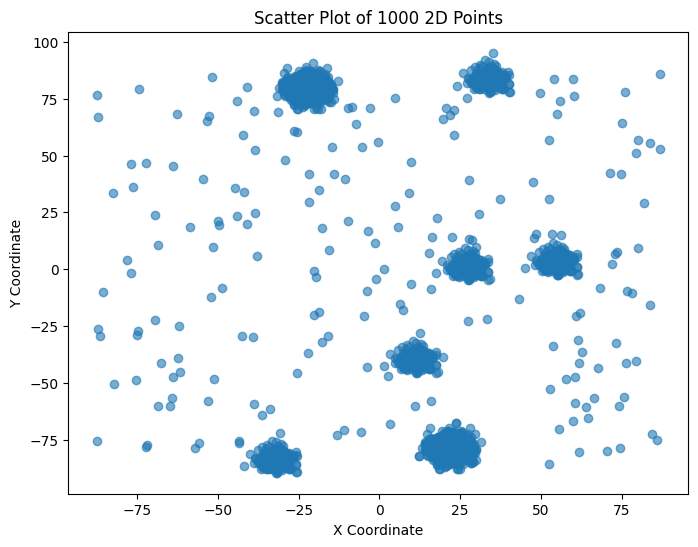

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a random numpy array of 1000 2D points
points = data_points

# Scatter plot these points
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], alpha=0.6)
plt.title('Scatter Plot of 1000 2D Points')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


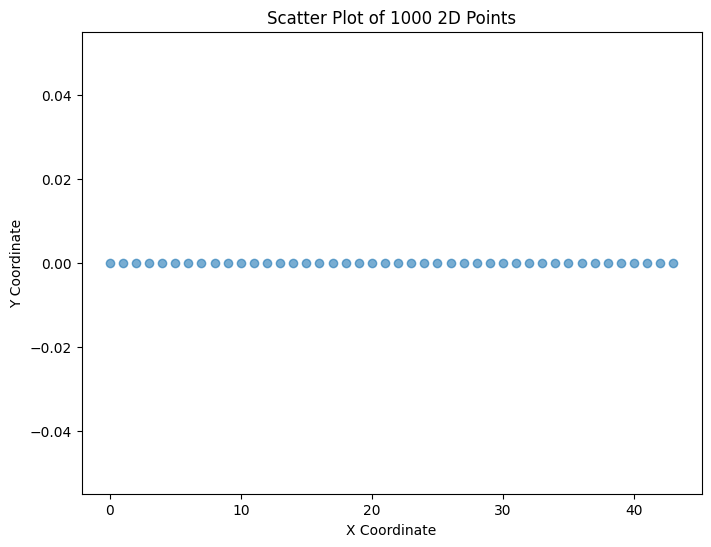

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a random numpy array of 1000 2D points
points = density_sample

# Scatter plot these points
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], alpha=0.6)
plt.title('Scatter Plot of 1000 2D Points')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


In [66]:
class DensitySOM:
    def __init__(self, density_samples):
        self.density_sample = density_sample
        self.som_size = self.density_sample.shape[0]
        self.som_locations = None
        self.som_centroids = None
        self.learning_rate_initial = learning_rate_initial

    def fit(self, X, iterations, sigma_initial, learning_rate_initial):
        self.som_centroids = X[np.random.choice(X.shape[0], self.som_size, replace=False)] if self.som_centroids is None else self.som_centroids

        for iteration in range(iterations):
            print(f'\rIteration {iteration}/{iterations}', end='')
            learning_rate = learning_rate_initial * np.exp(-iteration / iterations)
            sigma = sigma_initial * np.exp(-iteration / iterations)

            # Choose a random sample from the data
            sample = X[np.random.randint(X.shape[0])]

            # Find the winning neuron (the one closest to the sample)
            distances = np.linalg.norm(self.som_centroids - sample, axis=-1)
            winning_position = np.argmin(distances, axis=None)

            # Update the SOM weights
            for i in range(self.som_size):
                distance_to_winner = np.sqrt((self.density_sample[winning_position,0] - self.density_sample[i,0]) ** 2 
                                            +(self.density_sample[winning_position,1] - self.density_sample[i,1]) ** 2)
                weight_update = np.exp(-(distance_to_winner**2) / (2 * sigma**2))
                self.som_centroids[i] += learning_rate * weight_update * (sample - self.som_centroids[i])

    def plot_SOM(self, X):
        # Find the closest neighbor for each point
        self.som_centroids = X[np.random.choice(X.shape[0], self.som_size, replace=False)] if self.som_centroids is None else self.som_centroids

        closest_neighbors = {}
        for i, point in enumerate(self.density_sample):
            distances = np.sqrt(np.sum((self.density_sample - point)**2, axis=1))
            distances[i] = np.inf  # Exclude the point itself by setting its distance to infinity
            closest_neighbor_index = np.argmin(distances)
            closest_neighbors[i] = closest_neighbor_index

        # Plot the X
        plt.figure(figsize=(10, 10))
        plt.scatter(X[:, 0], X[:, 1], s=10)

        # Plot lines between each point and its closest neighbor
        for i, closest_neighbor_index in closest_neighbors.items():
            plt.plot([self.som_centroids[i][0], self.som_centroids[closest_neighbor_index][0]], 
                     [self.som_centroids[i][1], self.som_centroids[closest_neighbor_index][1]], 
                    'r-', linewidth=0.5)

        plt.title("2D Gaussian Points and Their Closest Neighbors")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.show()

    def plot_SOM_grid(self, X):
        # Find the closest neighbor for each point
        self.som_centroids = X[np.random.choice(X.shape[0], self.som_size, replace=False)] if self.som_centroids is None else self.som_centroids

        closest_neighbors = {}
        for i, point in enumerate(self.density_sample):
            distances = np.sqrt(np.sum((self.density_sample - point)**2, axis=1))
            distances[i] = np.inf  # Exclude the point itself by setting its distance to infinity
            
            closest_neighbors[i] = list()    
            for j in range(2):
                closest_neighbors[i].append(np.argsort(distances)[j])
            
        # Plot the X
        plt.figure(figsize=(10, 10))
        plt.scatter(X[:, 0], X[:, 1], s=10)

        # Plot lines between each point and its closest neighbor
        for i, point in enumerate(self.density_sample):#, closest_neighbor_index in closest_neighbors.items():
            for closest_neighbour in closest_neighbors[i]:
                
                plt.plot([self.som_centroids[i][0], self.som_centroids[closest_neighbour][0]], 
                    [self.som_centroids[i][1], self.som_centroids[closest_neighbour][1]], 
                    'r-', linewidth=0.5)

        plt.title("2D Gaussian Points and Their Closest Neighbors")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.show()
    


In [67]:
# import numpy as np
# import matplotlib.pyplot as plt
# from IPython.display import display, clear_output
# import time

# def plot_clustering(X, centroids, G, ax):
#     ax.clear()  # Clear previous plots
#     # Assign each point in X to the nearest centroid and get the color mapping for the plot
#     assignments = [closest_centroid(x, centroids) for x in X]
#     colors = plt.cm.viridis(np.linspace(0, 1, len(centroids)))

#     # Plotting the clusters and centroids
#     for idx, centroid in enumerate(centroids):
#         # Plot points assigned to this centroid
#         cluster_points = X[np.array(assignments) == idx]
#         ax.scatter(cluster_points[:, 0], cluster_points[:, 1], color='blue', s=10)
#         ax.scatter(centroid[0], centroid[1], color='red', s=50, edgecolors='black')

#     # Draw a red line between each centroid and the next
#     for i in range(len(centroids)):
#         for j in G[i]:
#             ax.plot([centroids[i][0], centroids[j][0]], [centroids[i][1], centroids[j][1]], 'r-')
#         #ax.plot([centroids[i][0], centroids[i+1][0]], [centroids[i][1], centroids[i+1][1]], 'r-')

#     ax.set_title('Online K-means Clustering')
#     ax.set_xlabel('X Coordinate')
#     ax.set_ylabel('Y Coordinate')

# ############################################################################################################



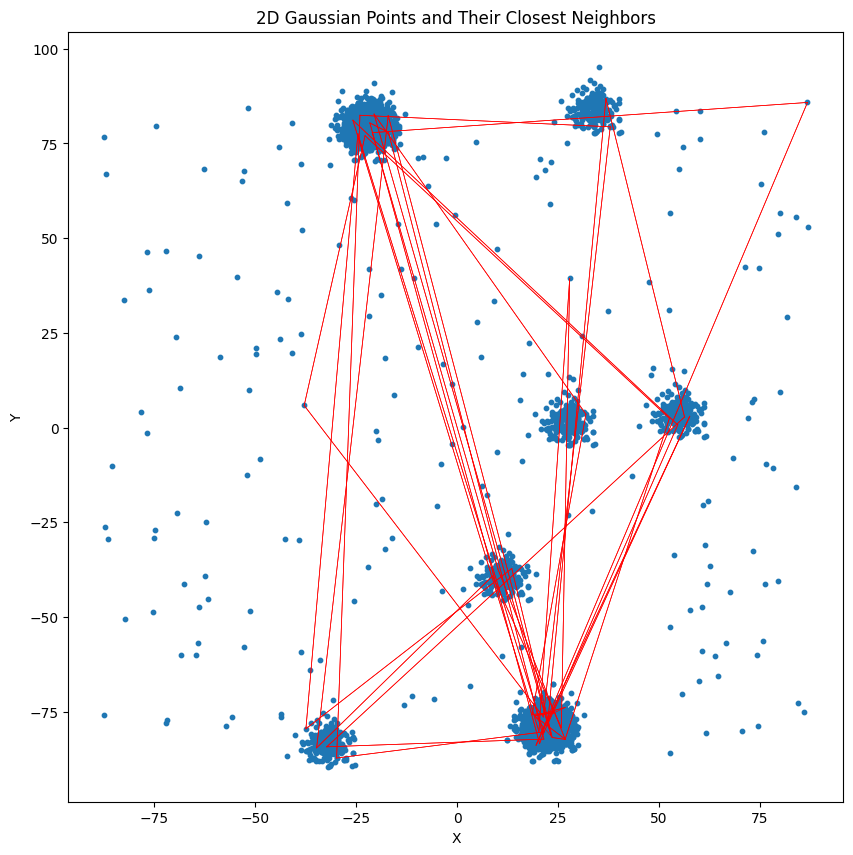

In [68]:
densitySOM = DensitySOM(density_sample)
# densitySOM = DensitySOM(density_sample) FOR CIRCLE
densitySOM.plot_SOM_grid(data_points)


Iteration 3999/4000

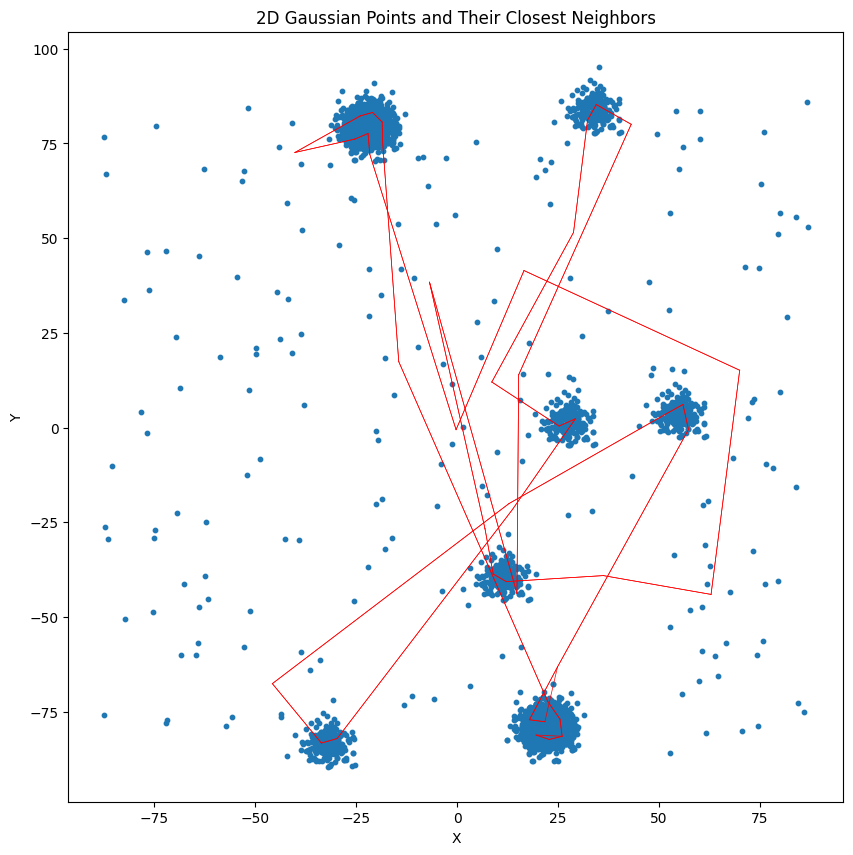

Iteration 3999/4000

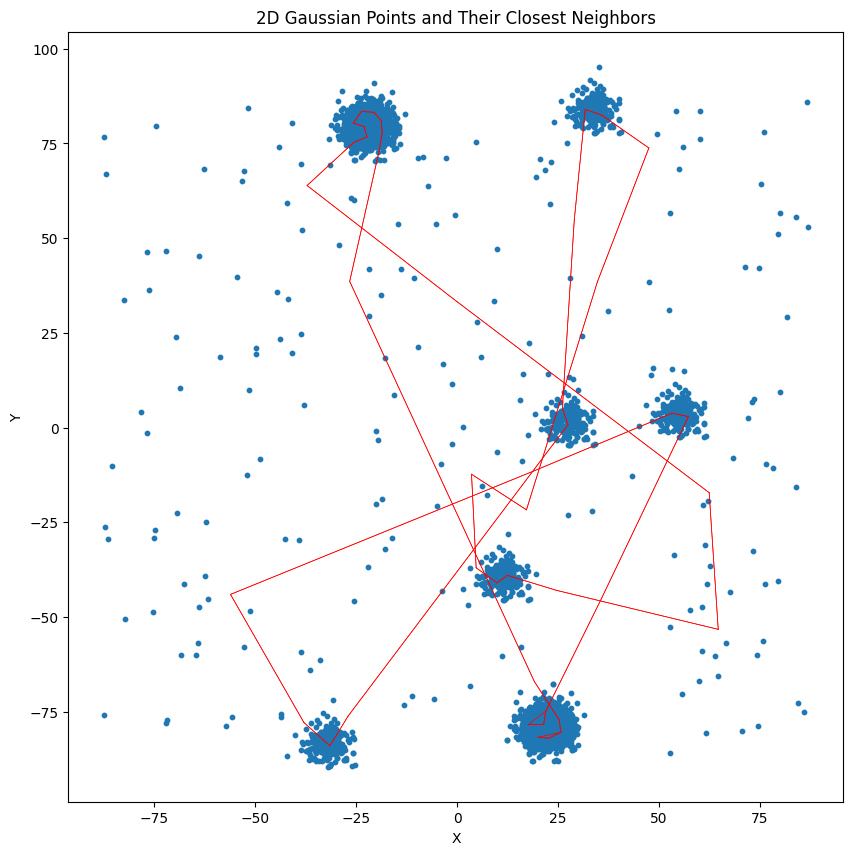

Epoch 1/2

In [69]:
EPOCH_NUM = 2
for epoch in range(EPOCH_NUM):
    print(f'\rEpoch {epoch}/{EPOCH_NUM}', end='')
    densitySOM.fit(data_points, iterations=4000, sigma_initial=1, learning_rate_initial=0.1)
    densitySOM.plot_SOM_grid(data_points)
    print(f'\rEpoch {epoch}/{EPOCH_NUM}', end='')

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

class DensitySOM:
    def __init__(self, density_samples, learning_rate_initial=0.1):
        self.density_sample = density_samples
        self.som_size = self.density_sample.shape[0]
        self.som_locations = None
        self.som_centroids = None
        self.learning_rate_initial = learning_rate_initial

    def fit(self, X, iterations, sigma_initial, learning_rate_initial, plot_interval=None):
        self.som_centroids = X[np.random.choice(X.shape[0], self.som_size, replace=False)] if self.som_centroids is None else self.som_centroids

        for iteration in range(iterations):
            print(f'\rIteration {iteration}/{iterations}', end='')
            learning_rate = learning_rate_initial * np.exp(-iteration / iterations)
            sigma = sigma_initial * np.exp(-iteration / iterations)

            # Choose a random sample
            sample = X[np.random.randint(X.shape[0])]
            
            # Find winning neuron
            distances = np.linalg.norm(self.som_centroids - sample, axis=-1)
            winning_position = np.argmin(distances, axis=None)

            # Update SOM weights
            for i in range(self.som_size):
                distance_to_winner = np.sqrt(
                    (self.density_sample[winning_position,0] - self.density_sample[i,0])**2 +
                    (self.density_sample[winning_position,1] - self.density_sample[i,1])**2
                )
                weight_update = np.exp(-(distance_to_winner**2) / (2 * sigma**2))
                self.som_centroids[i] += learning_rate * weight_update * (sample - self.som_centroids[i])

            # Live plotting
            if plot_interval and iteration % plot_interval == 0:
                self._plot_current_state(X, iteration, iterations)

    def _plot_current_state(self, X, iteration=None, total_iterations=None):
        """Helper function for live plotting (modified animation approach)"""
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Find closest neighbors
        closest_neighbors = {}
        for i, point in enumerate(self.density_sample):
            distances = np.sqrt(np.sum((self.density_sample - point)**2, axis=1))
            distances[i] = np.inf
            closest_neighbors[i] = np.argsort(distances)[:2]  # Get 2 closest neighbors

        # Plot data points
        ax.scatter(X[:, 0], X[:, 1], s=10, color='blue', alpha=0.5)
        
        # Plot SOM grid connections
        for i in range(self.som_size):
            for neighbor in closest_neighbors[i]:
                ax.plot(
                    [self.som_centroids[i][0], self.som_centroids[neighbor][0]],
                    [self.som_centroids[i][1], self.som_centroids[neighbor][1]],
                    'r-', linewidth=0.8, alpha=0.8
                )
        
        # Plot SOM nodes
        ax.scatter(
            self.som_centroids[:, 0], 
            self.som_centroids[:, 1], 
            s=50, color='red', edgecolor='black', marker='o'
        )

        # Configure plot
        title = "SOM Grid"
        if iteration is not None:
            title += f" | Iteration {iteration}/{total_iterations}"
        ax.set_title(title)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(True)
        
        # Display and clear
        display(fig)
        time.sleep(0.1)  # Control animation speed
        clear_output(wait=True)
        plt.close(fig)

    def plot_SOM_grid(self, X):
        """Final plot after training"""
        if self.som_centroids is None:
            raise ValueError("Train SOM first using fit()")
        self._plot_current_state(X)

In [71]:
som = DensitySOM(density_samples=density_sample)


In [73]:
som.fit(data_points, iterations=1000, sigma_initial=2.0, 
        learning_rate_initial=0.5, plot_interval=10)

Iteration 999/1000

## MNIST

In [74]:


# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import TSNE


# Step 1: Download MNIST dataset
mnist = datasets.fetch_openml('mnist_784', version=1)
X, y = mnist.data.to_numpy(), mnist.target.astype(int)

# Step 2: Select only digits representing DIGIT
DIGIT = 1
X_ones = X[y == DIGIT]

# Step 4: Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_ones)


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn import datasets
from sklearn.manifold import TSNE

def plotMNIST2d(X_mnist, X_embed, subset_size=None):
    if subset_size is None:
        subset_size = X_mnist.size
    random_indices = np.random.choice(X_mnist.shape[0], size=subset_size, replace=False)

    # Step 5: Scatterplot with digit markers
    _, ax = plt.subplots(figsize=(12, 12))
    _ = ax.scatter(X_embed[random_indices, 0], X_embed[random_indices, 1])
    # Annotate a few points with their digit images
    for i in random_indices:  # Adjust the step for more/less images
        digit_image = X_mnist[i,:].reshape(28, 28)
        imagebox = OffsetImage(digit_image, zoom=0.5, cmap='binary')
        ab = AnnotationBbox(imagebox, (X_embed[i, 0], X_embed[i, 1]), frameon=False)
        ax.add_artist(ab)

    ax.set_title('MNIST embeddings 2D')
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')

    plt.show()


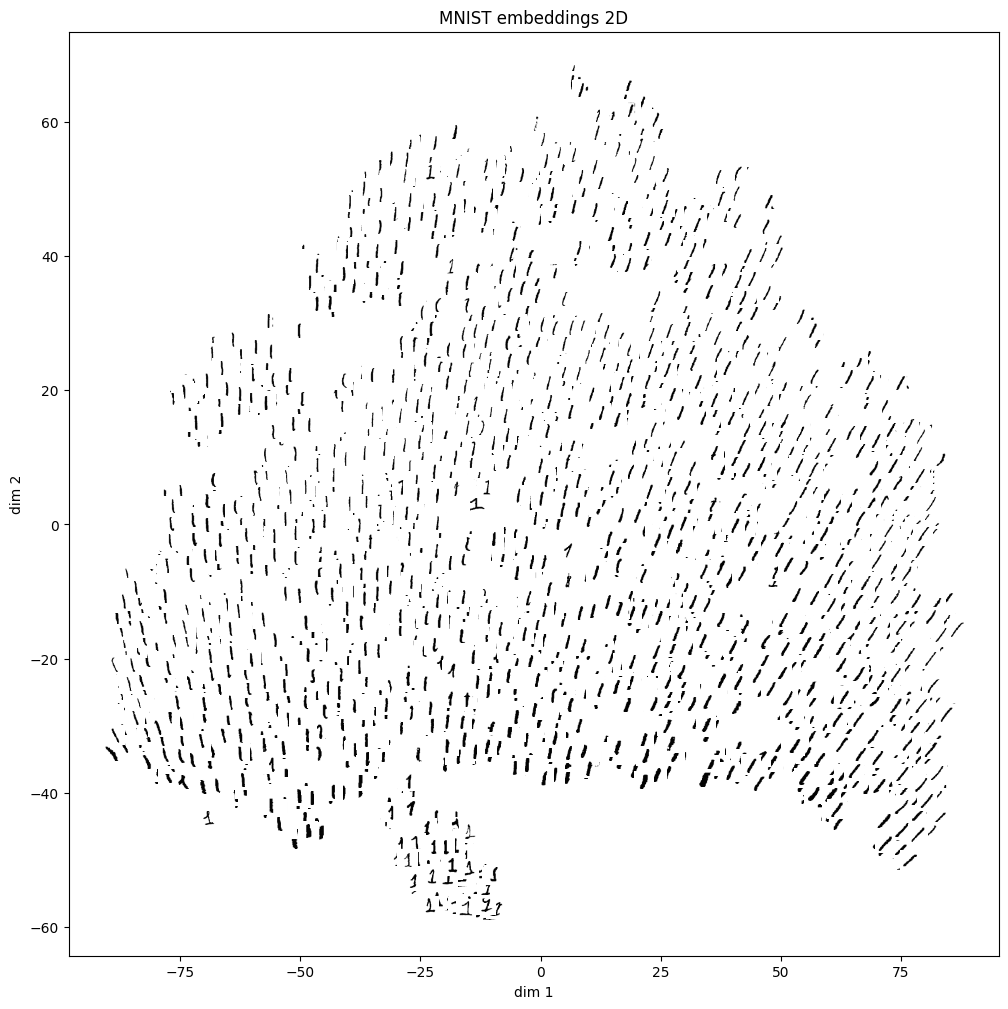

In [76]:
plotMNIST2d(X_ones, X_tsne, subset_size=4000)

In [16]:
!pip install minisom

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import TSNE


# Step 1: Download MNIST dataset
mnist = datasets.fetch_openml('mnist_784', version=1)
X, y = mnist.data.to_numpy(), mnist.target.astype(int)

# Step 2: Select only digits representing DIGIT
DIGIT = 1
X_ones = X[y == DIGIT]

# Step 3: Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_ones)


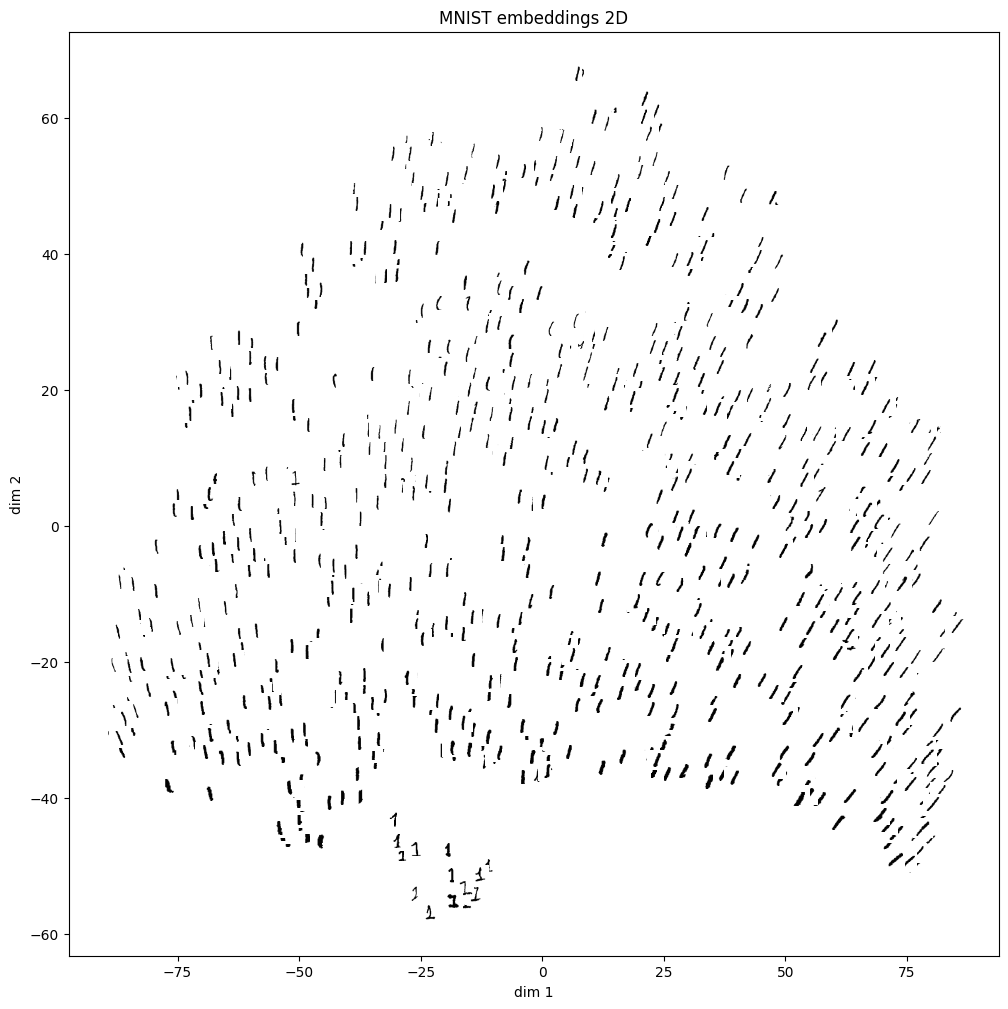

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn import datasets
from sklearn.manifold import TSNE

def plotMNISTkohonen(X_mnist, X_embed, subset_size=None):
    if subset_size is None:
        subset_size = X_mnist.size
    random_indices = np.random.choice(X_mnist.shape[0], size=subset_size, replace=False)

    # Step 5: Scatterplot with digit markers
    _, ax = plt.subplots(figsize=(12, 12))
    _ = ax.scatter(X_embed[random_indices, 0], X_embed[random_indices, 1])
    # Annotate a few points with their digit images
    for i in random_indices:  # Adjust the step for more/less images
        digit_image = X_mnist[i,:].reshape(28, 28)
        imagebox = OffsetImage(digit_image, zoom=0.5, cmap='binary')
        ab = AnnotationBbox(imagebox, (X_embed[i, 0], X_embed[i, 1]), frameon=False)
        ax.add_artist(ab)

    ax.set_title('MNIST embeddings 2D')
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')

    plt.show()

plotMNISTkohonen(X_ones, X_tsne, subset_size=999)


In [77]:
# Step 4: Run MiniSOM
from minisom import MiniSom

som_size = 10  # For simplicity, we'll use a 5x5 grid. Adjust as needed.
som = MiniSom(som_size, som_size, 2, sigma=1.0, learning_rate=0.5)
som.train_random(X_tsne, 10000) 

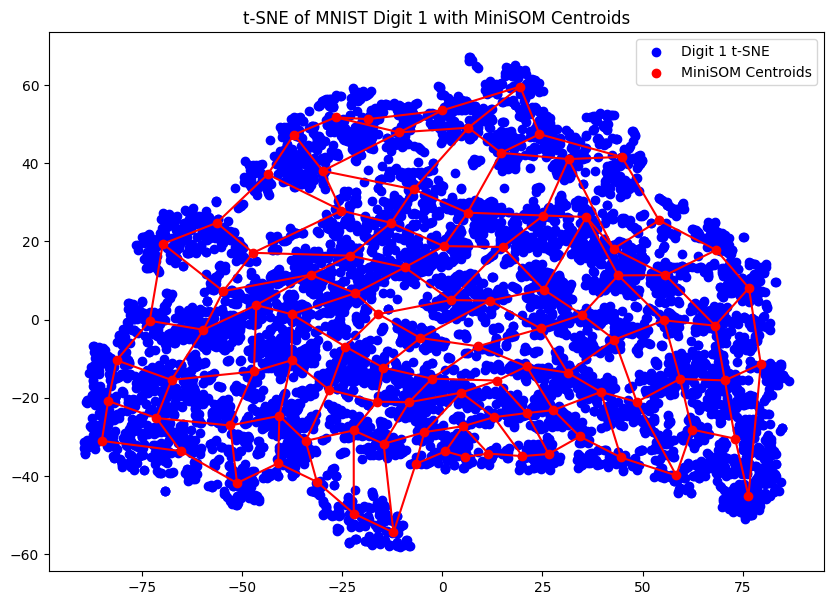

In [78]:
# Step 4: Scatterplot t-SNE results
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], color='blue', label='Digit 1 t-SNE')

# Step 5: Scatterplot MiniSOM centroids and connect them
weights_tsne = som.get_weights().reshape(som_size*som_size, -1)
#weights_tsne = tsne.fit_transform(weights)  # Reduce SOM weights to 2D to plot
plt.scatter(weights_tsne[:, 0], weights_tsne[:, 1], color='red', label='MiniSOM Centroids')

# Connect centroids according to MiniSOM grid topology
for i in range(som_size):
    for j in range(som_size):
        if i+1 < som_size:  # Connect vertically
            plt.plot(weights_tsne[[i*som_size+j, (i+1)*som_size+j], 0],
                     weights_tsne[[i*som_size+j, (i+1)*som_size+j], 1], color='red')
        if j+1 < som_size:  # Connect horizontally
            plt.plot(weights_tsne[[i*som_size+j, i*som_size+(j+1)], 0],
                     weights_tsne[[i*som_size+j, i*som_size+(j+1)], 1], color='red')

plt.legend()
plt.title('t-SNE of MNIST Digit 1 with MiniSOM Centroids')
plt.show()


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn import datasets
from sklearn.manifold import TSNE
from minisom import MiniSom

# Load MNIST data and filter for digit 1
mnist = datasets.fetch_openml('mnist_784', version=1)
X, y = mnist.data.to_numpy(), mnist.target.astype(int)
DIGIT = 1
X_ones = X[y == DIGIT]

# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_ones)


In [59]:
# Train SOM on t-SNE embeddings
som_size = 16
som = MiniSom(som_size, som_size, 2, sigma=1.0, learning_rate=0.5)


NameError: name 'MiniSom' is not defined

In [58]:

som.train_random(X_tsne, 100000)  # 10,000 iterationsCfwfwkxxsb4a


AttributeError: 'DensitySOM' object has no attribute 'train_random'

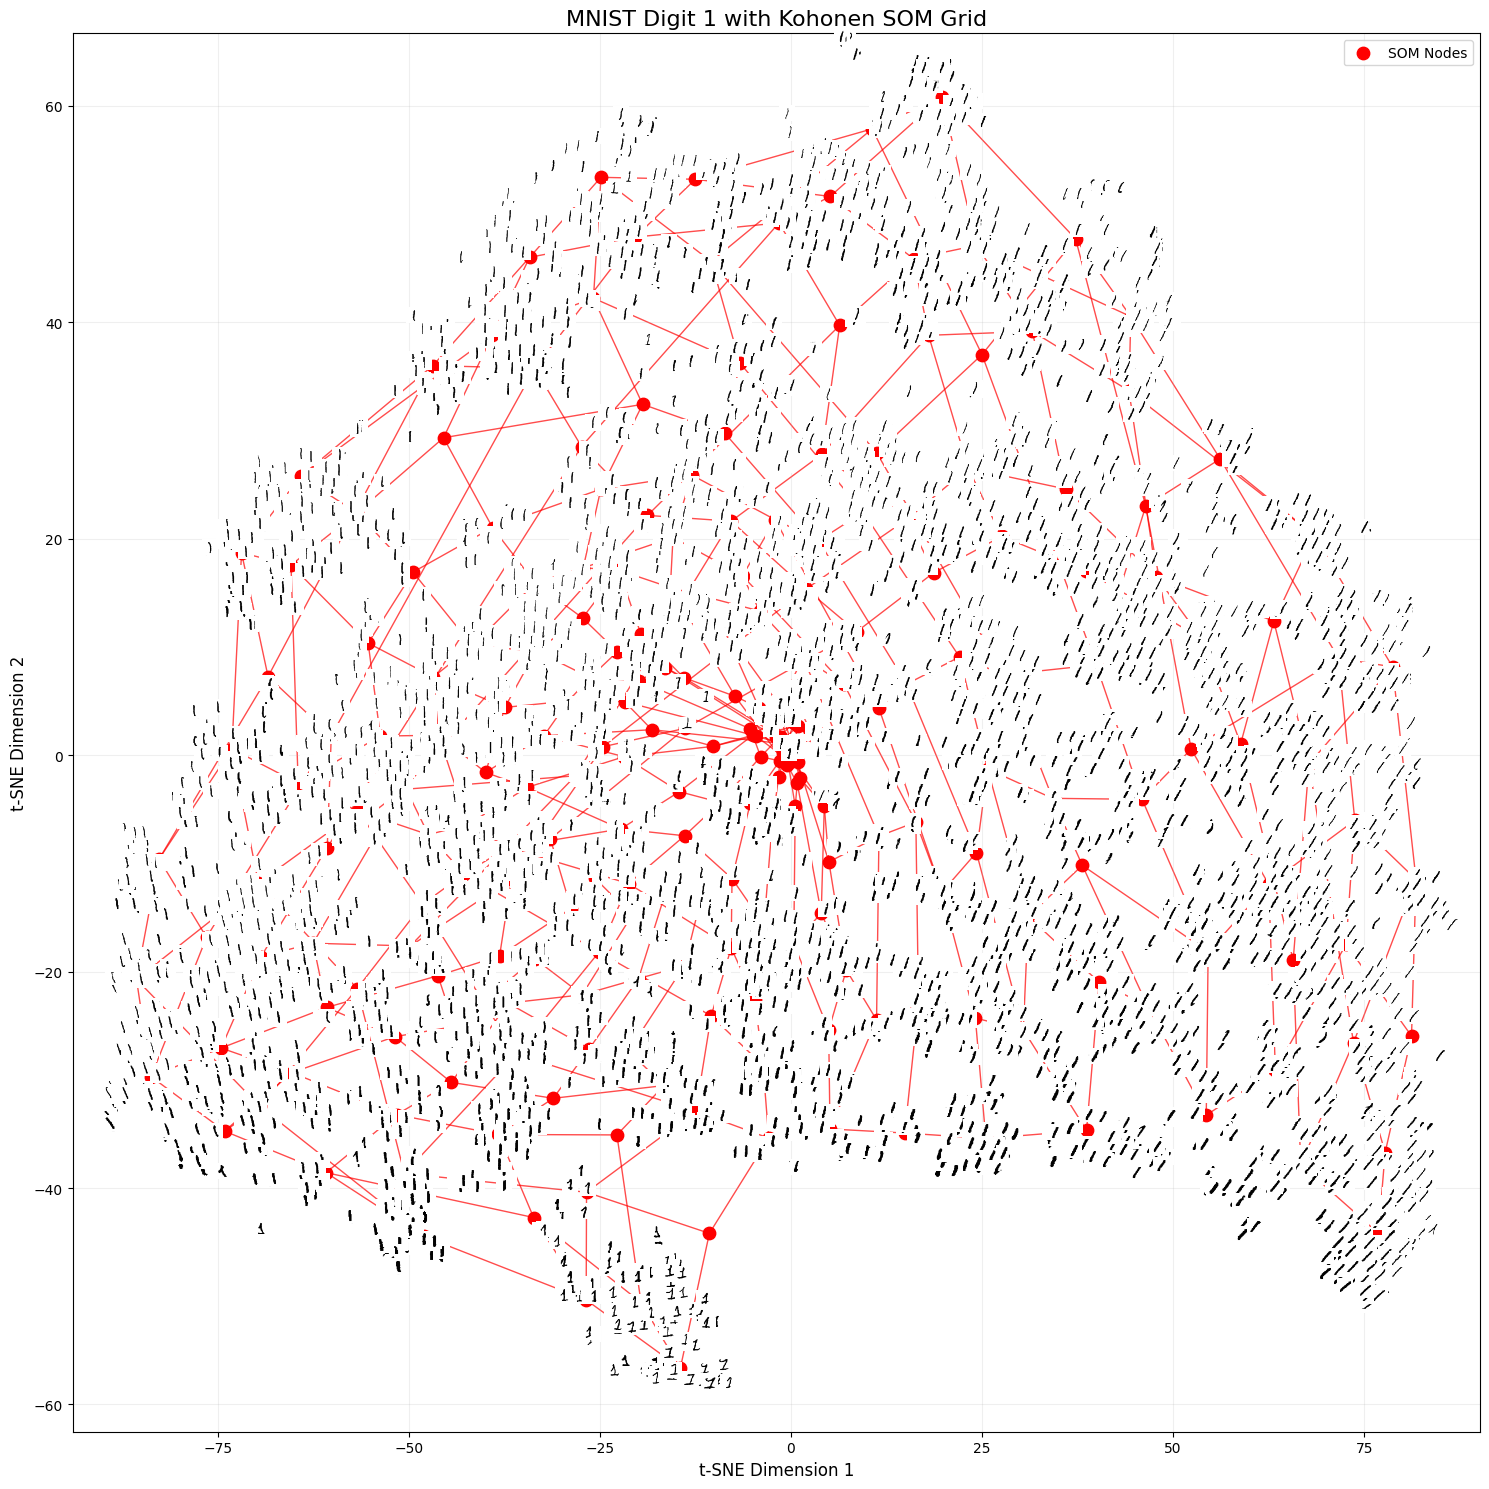

In [24]:


def plot_mnist_with_som(X_mnist, X_embed, som, som_size, subset_size=500):
    """
    Visualize MNIST digits with t-SNE embeddings and Kohonen SOM overlay
    
    Parameters:
    X_mnist: Original MNIST images (n_samples, 784)
    X_embed: 2D embeddings (n_samples, 2)
    som: Trained MiniSom object
    som_size: Size of SOM grid (som_size x som_size)
    subset_size: Number of digits to display
    """
    # Random subset selection
    random_indices = np.random.choice(X_mnist.shape[0], size=subset_size, replace=False)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Get SOM weights and reshape
    weights = som.get_weights()
    weights_flat = weights.reshape(som_size*som_size, -1)
    
    # Plot SOM grid connections (behind digits)
    for i in range(som_size):
        for j in range(som_size):
            if i+1 < som_size:  # Vertical connections
                idx1 = i*som_size + j
                idx2 = (i+1)*som_size + j
                ax.plot([weights_flat[idx1, 0], weights_flat[idx2, 0]],
                        [weights_flat[idx1, 1], weights_flat[idx2, 1]], 
                        'r-', alpha=0.7, linewidth=1, zorder=1)
            if j+1 < som_size:  # Horizontal connections
                idx1 = i*som_size + j
                idx2 = i*som_size + (j+1)
                ax.plot([weights_flat[idx1, 0], weights_flat[idx2, 0]],
                        [weights_flat[idx1, 1], weights_flat[idx2, 1]], 
                        'r-', alpha=0.7, linewidth=1, zorder=1)
    
    # Plot SOM nodes (behind digits)
    ax.scatter(weights_flat[:, 0], weights_flat[:, 1], 
               c='red', s=80, marker='o', edgecolor='red', 
               label='SOM Nodes', zorder=2)
    
    # Plot MNIST digits (on top)
    for i in random_indices:
        digit_img = X_mnist[i].reshape(28, 28)
        img = OffsetImage(digit_img, zoom=0.4, cmap='binary')
        ab = AnnotationBbox(img, (X_embed[i, 0], X_embed[i, 1]), 
                            frameon=False, pad=0.0)
        ax.add_artist(ab)
    
    # Enhancements
    ax.set_title(f'MNIST Digit {DIGIT} with Kohonen SOM Grid', fontsize=16)
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.legend(loc='upper right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# Generate the visualization
plot_mnist_with_som(X_ones, X_tsne, som, som_size, subset_size=5000)

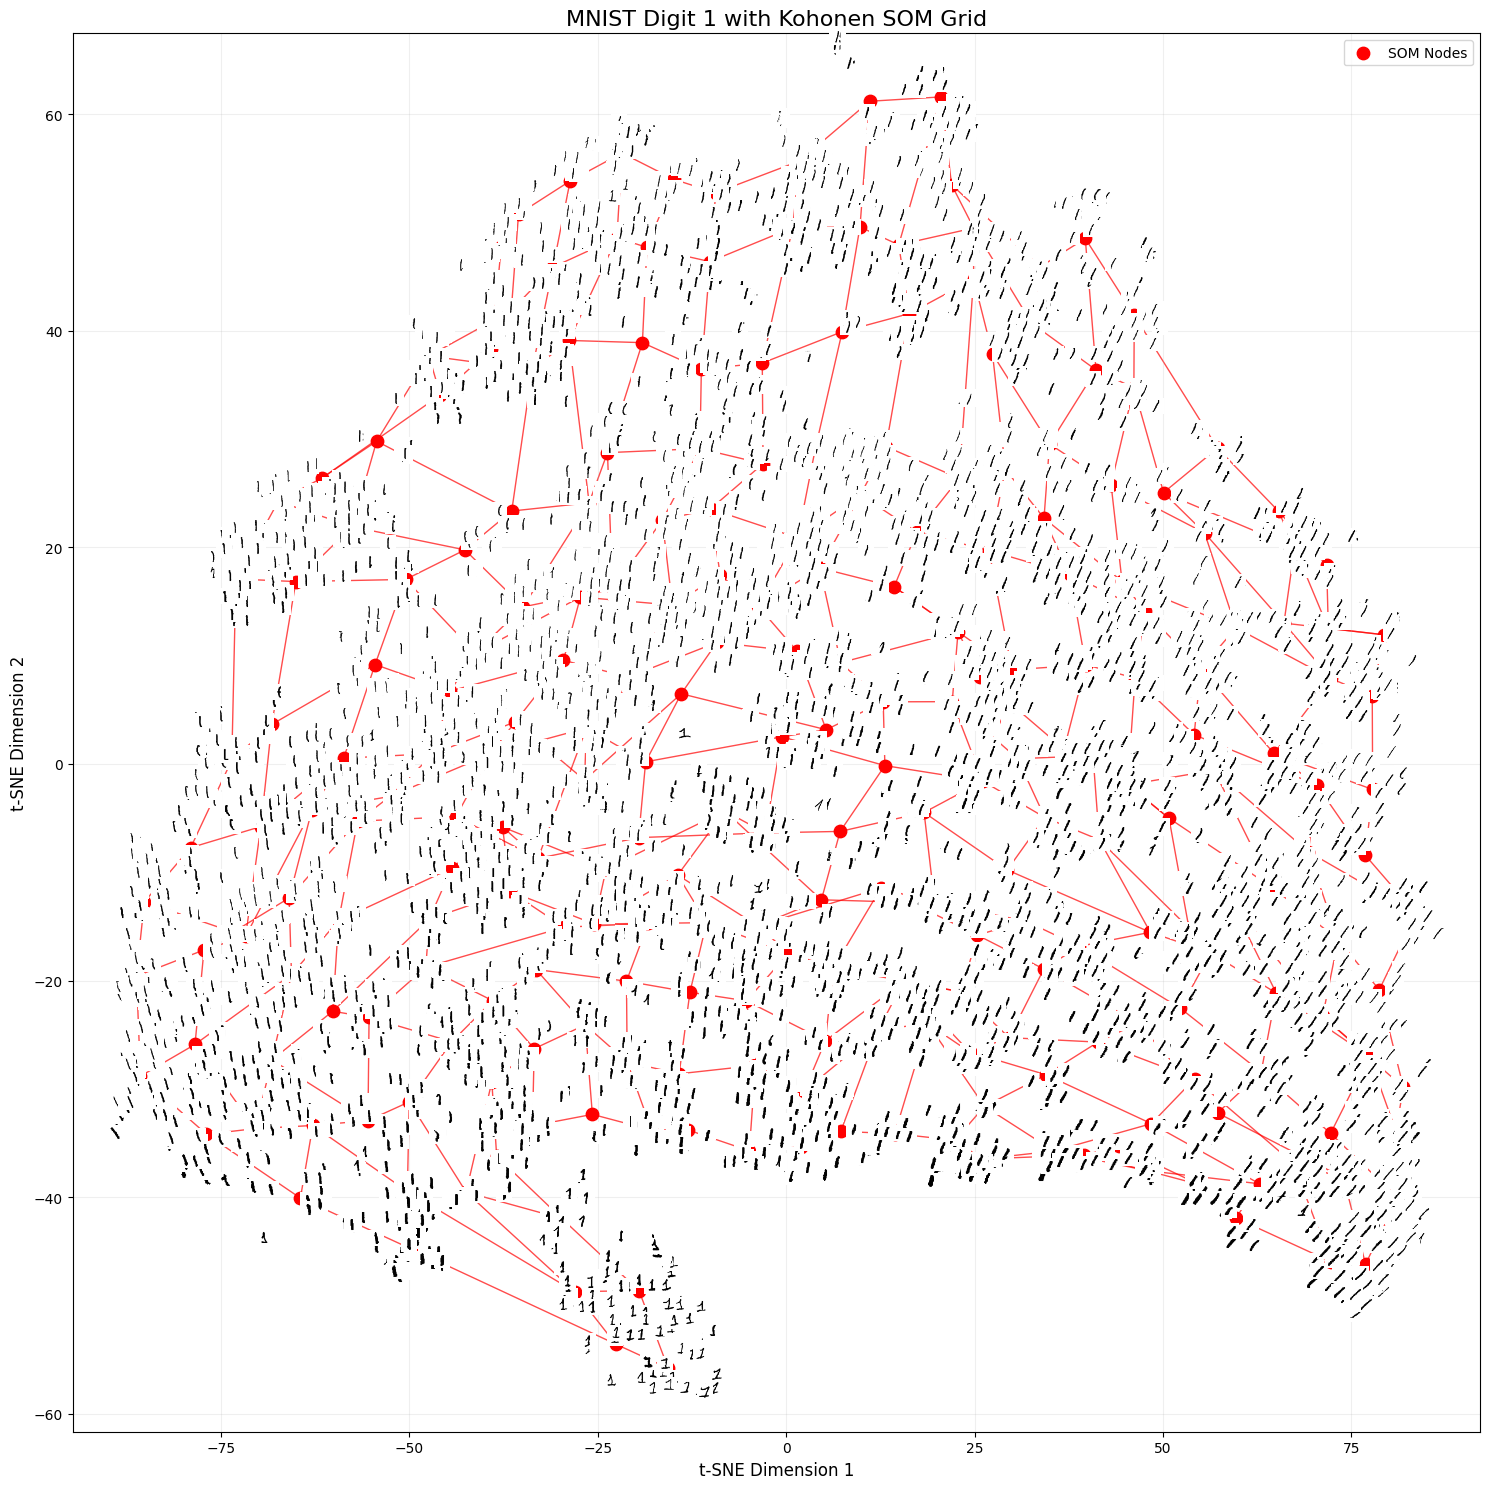

In [25]:

som.train_random(X_tsne, 100000)  # 10,000 iterationsCfwfwkxxsb4a

# Generate the visualization
plot_mnist_with_som(X_ones, X_tsne, som, som_size, subset_size=5000)